## **Outline**

### **1. Introduction**
   - The following genes produce enzymes that are used to metabolize drugs (primarily in the liver):
       1. ***CYP2C8***: regulates many drugs, including anticancer, diabetes and blood pressure drugs
       2. ***CYP2C9***: regulates many common drugs, including warfarin / Coumadin and NSAIDs such as Advil
       3. ***CYP2C19***: regulates… yup, many common drugs, including antiplatelet drugs, antidepressants and anti-epileptic drugs.
       
   - These genes are generally found on the same chromosome within the human genome within human beings that are products of viable pregnancies. The different chromosomes are not known to interact with each other in any significant way, so it's safe to only download the chromosome where these genes are located for analysis. For the case of these genes, the chromosome of interest is chromosome 10.

   - Chromosome 10 of the human genome is downloaded from UCSC Genome Browser in the Fasta format. The GRCh38/hg38 sample is used as a reference genome for this analysis.

   - We are interested in identifying variants in 2 seperate samples. One sample is from illumina sequencing, the other is from a pacbio sequencer.

   - ***Illumina Reads:***
      - **These are interleaved paired end reads:**
        
         - **Paired End Read:** each fragment is sequenced from both ends of the strand that is sequenced. The forward reads can be considered to be part of a collection $R_f$, while the reverse reads can be considered to be part of the collection $R_r$.
         
         - **Interleaved:** reads from both collections $R_f$ and $R_r$ are stored in the same file. Read 1 in $R_r$ and Read 1 in $R_f$ are stored right next to one another.
   - ***PacBio Reads:***
        
        - Our Pacbio reads are long single-end  Circular concensus sequencing reads. According to PacBio these reads are more than 99% accurate. A second opinion on this statement would be nice to have.
        - These reads are long and accurate as they are based on a consensus of multiple passes of the same strand.

### **2. Objectives**
   - We intend to use bioinformatics tools to locate variations in the following genes of interest within the human genome: CYP2C8, CYP2C9, and CYP2C19.

### **3. Rough Steps**

1. ***Setup***: Install necessary tools and download human genome reference and reads for alignment

2. ***Alignment***: Align each set of reads to the reference genome using minimap2

3. ***Variant Calling & Phasing***: Find haplotype variants in each sample using GATK HaplotypeCaller

4. ***Analysis***: Compare/contrast the two variant call files. See if the variants are sequencing issues or true variants with screenshots of locations of variants within each gene of interest using IGV and vcf comparion tools.

5. ***Conclusion***: Find the star-allele for each gene of interest in each sample using PharmVar database. A star allele



# **1. Setup**
First we download the samples from github and the reference genome from UCSC Genome Browser.
The necessary tools should be included in the docker container which is mandatory for this project.

Software toolkit:
- ***Docker:*** for ease of use of the following tools
    - ***minimap2:*** for alignment of samples to reference genome
    - ***samtools:*** for general manipulation/binary indexing of alignment files
    - ***GATK HaplotypeCaller:*** for variant calling and phasing
    - ***IGV:*** for visualization of variants
    - ***PharmVar Dsatabase:*** for determining star-alleles of genes of interest
    - ***Python 3***: For running the notebook
    - ***Python libraries in requirements.txt***: For running the notebook

In [1]:
%%bash
docker pull broadinstitute/gatk # Make sure that the docker image for gatk is installed

# Make the directories required
cd data 
for dir in alignments gatk_output reads ref_genome notebook_outputs; do
  [ -d "$dir" ] && rm -rf "$dir"
done
mkdir alignments && mkdir gatk_output && mkdir reads && mkdir ref_genome && mkdir notebook_outputs

# Download the read and reference files, unzip pem.
cd reads && wget https://github.com/inumanag/fall25-csc-bioinf/raw/refs/heads/main/week4/data/illumina.fq.bz2 -O illumina.fq.bz2 -q 
wget https://github.com/inumanag/fall25-csc-bioinf/raw/refs/heads/main/week4/data/pacbio.fq.bz2 -O pacbio.fq.bz2 -q
bzip2 -df *.fq.bz2

# Download reference genome
cd ../ref_genome && wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr10.fa.gz -O chr10.fa.gz -q
gunzip -df *.gz

Using default tag: latest


latest: Pulling from broadinstitute/gatk
Digest: sha256:71b17ee42d149e8ec112603f5305c873ab60d93949ef8bb62a4fff85427f56fb
Status: Image is up to date for broadinstitute/gatk:latest
docker.io/broadinstitute/gatk:latest


Exception in thread Thread-7 (bg_main):
Traceback (most recent call last):
  File "/tmp/ipykernel_22956/942449381.py", line 17, in bg_main
  File "/home/kelloggs/miniconda3/envs/codon_bio/lib/python3.10/site-packages/IPython/core/display_functions.py", line 374, in update
    update_display(obj, display_id=self.display_id, **kwargs)
  File "/home/kelloggs/miniconda3/envs/codon_bio/lib/python3.10/site-packages/IPython/core/display_functions.py", line 326, in update_display
    display(obj, display_id=display_id, **kwargs)
  File "/home/kelloggs/miniconda3/envs/codon_bio/lib/python3.10/site-packages/IPython/core/display_functions.py", line 296, in display
    publish_display_data(data=obj, metadata=metadata, **kwargs)
  File "/home/kelloggs/miniconda3/envs/codon_bio/lib/python3.10/site-packages/IPython/core/display_functions.py", line 93, in publish_display_data
    display_pub.publish(
  File "/home/kelloggs/miniconda3/envs/codon_bio/lib/python3.10/site-packages/ipykernel/zmqshell.py", 

In [ ]:
%pip install -qpandas
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/refGene.txt.gz -O refGene.txt.gz
import os
import pandas as pd
# from python_utilities.file_tools import FastQ



cwd = os.getcwd()
# print(cwd) # Default working directory is parent dir of this journal



link_to_short_read_illumina_fastq_file = "https://github.com/inumanag/fall25-csc-bioinf/raw/refs/heads/main/week4/data/illumina.fq.bz2"


link_to_long_read_pacbio_fastq_file = 'https://github.com/inumanag/fall25-csc-bioinf/raw/refs/heads/main/week4/data/pacbio.fq.bz2'

genome_browser_api_base_uri = "https://api.genome.ucsc.edu/"

hu_genome_chrom_10_uri = genome_browser_api_base_uri + "getData/sequence?genome=hg38;chrom=chr10"

# The chromosome 10 file is located on a mercurial server at UCSC. # We can use wget/curl to download the chromosome 10 file with the following link
hg38_chromosme_10_url = 'https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr10.fa.gz'




# def load_fq_file_as_dict(file_path:str) -> dict:

#     with open(file_path) as fq_file:
#         fq_string = fq_file.read()
#         return FastQ.get_fastq_as_dict(fq_string)
    
# def load_fq_file_as_list(file_path:str ) -> list[FastQ.FastQEntry]:
#     pass
#     with open(file_path) as fq_file:
#         fq_string = fq_file.read()
#         return FastQ.get_fastq_as_list(fq_string)

illumina_path = "data/illumina.fq"
pacbio_path = "data/pacbio.fq"


Note: you may need to restart the kernel to use updated packages.
--2025-11-03 23:24:57--  https://hgdownload.soe.ucsc.edu/goldenPath/hg38/database/refGene.txt.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8668756 (8.3M) [application/x-gzip]
Saving to: ‘refGene.txt.gz.4’

refGene.txt.gz.4    100%[===================>]   8.27M  7.84MB/s    in 1.1s    

2025-11-03 23:24:58 (7.84 MB/s) - ‘refGene.txt.gz.4’ saved [8668756/8668756]



# **2. Alignment with minimap2**

We now have a reference genome and two separate samples that we would like to align to each reference genome. For the actual alignment we will use minimap2 with parameters to fit the format of each sample's file. Minimap2 outputs alignments in the SAM format, which is a human readable text format for storing sequence alignments. For more universal use, the SAM file can be converted to the BAM format, which is a binary format that is more efficient for storage and processing.


The minimap2 tool is used to align a set of reads to a reference genome. It has a lot of different options that are hard to keep track of. For this purpose I have included the relevant help output for minimap2 here for reference:
Usage: minimap2 [options] <target.fa>|<target.idx> [query.fa] [...]
```
Options:
Input/Output:
    -a           output in the SAM format (PAF by default)

Preset:
    -x STR       preset (always applied before other options; see minimap2.1 for details) []
                - lr:hq - accurate long reads (error rate <1%) against a reference genome
                - splice/splice:hq - spliced alignment for long reads/accurate long reads
                - splice:sr - spliced alignment for short RNA-seq reads
                - asm5/asm10/asm20 - asm-to-ref mapping, for ~0.1/1/5% sequence divergence
                - sr - short reads against a reference
                - map-pb/map-hifi/map-ont/map-iclr - CLR/HiFi/Nanopore/ICLR vs reference mapping
                - ava-pb/ava-ont - PacBio CLR/Nanopore read overlap
```



Alignment in text-based SAM format to stdout ⟶ Add readgroup tag to reads ⟶ sort reads by occurence in genome into a binary BAM file ⟶ index sorted BAM files, generating a .BAI index file
The regroup read tag is required for GATK HaplotypeCaller to function properly later on in the analysis.

```bash
minimap2 -ax <PRESET> <path_to_ref_genome> <path_to_sample_read> | samtools addreplacerg -r '@RG\tID:rg1\tSM:pacbio_sample1\tPL:PACBIO' -o - -| samtools sort -O bam -o <path_to_output_bam> aligned_sorted_pacbio.bam && samtools index <path_to_output_bam>
```

Here a SAM file is generated representing an alignment to a reference genome (https://epi2me.nanoporetech.com/notebooks/Introduction_to_SAM_and_BAM_files.html). This SAM alignment file is piped to samtools sort which adds a readgroup tag and sorts the alignments and outputs a sorted Binary version of the alignment file (BAM). The sorted BAM file is then indexed with samtools index for easier access to specific regions of the genome.

```bash
    # Include this in the path or install minimap2 with apt so you can run minimap2 without having to know where it is:
     ~/minimap2
```




In [ ]:
%%bash


# # Download the latest release (replace URL with the latest version)
wget https://github.com/lh3/minimap2/releases/download/v2.30/minimap2-2.30_x64-linux.tar.bz2 -O minimap2-2.30_x64-linux.tar.bz2

# # Extract the tarball
tar -xvjf minimap2-2.30_x64-linux.tar.bz2

# # Move the binary to a folder in your PATH
sudo mv minimap2-2.30_x64-linux/minimap2 /usr/local/bin/

# Test installation
minimap2 --version

sudo apt-get install -y samtools


# Uses minimap2 to align the reads to the reference genome and then uses samtools to sort and index the resulting BAI and BAM files.

#The "a" in the -ax combined argument tells minimap2 to output in the SAM format. The "x map-hifi" arg uses a preset made specifically for our PacBio hifi/ccs reads. 
minimap2 -ax map-hifi data/ref_genome/chr10.fa data/reads/pacbio.fq \
  | samtools addreplacerg -r '@RG\tID:rg1\tSM:pacbio_sample1\tPL:PACBIO' -o - -| samtools sort -O bam -o data/alignments/aligned_sorted_pacbio.bam\
    && samtools index data/alignments/aligned_sorted_pacbio.bam

#The "a" in the -ax combined argument tells minimap2 to output in the SAM format. The "x sr" arg uses a preset made for short length reads, our illumina reads are considered short at 150bp. 
minimap2 -ax sr data/ref_genome/chr10.fa data/reads/illumina.fq\
   | samtools addreplacerg -r '@RG\tID:rg1\tSM:illumina_sample_1\tPL:ILLUMINA' -o - -| samtools sort -O bam -o data/alignments/aligned_sorted_illumina.bam \
    && samtools index data/alignments/aligned_sorted_illumina.bam


2.30-r1287


[M::mm_idx_gen::2.580*1.00] collected minimizers
[M::mm_idx_gen::2.866*1.20] sorted minimizers
[M::main::2.866*1.20] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::3.013*1.19] mid_occ = 110
[M::mm_idx_stat] kmer size: 19; skip: 19; is_hpc: 0; #seq: 1
[M::mm_idx_stat::3.103*1.18] distinct minimizers: 11183865 (96.18% are singletons); average occurrences: 1.195; average spacing: 10.008; total length: 133797422
[M::worker_pipeline::4.129*1.58] mapped 3063 sequences
[M::main] Version: 2.30-r1287
[M::main] CMD: minimap2 -ax map-hifi data/ref_genome/chr10.fa data/reads/pacbio.fq
[M::main] Real time: 4.174 sec; CPU: 6.550 sec; Peak RSS: 0.683 GB
[M::mm_idx_gen::3.185*1.00] collected minimizers
[M::mm_idx_gen::3.593*1.22] sorted minimizers
[M::main::3.593*1.22] loaded/built the index for 1 target sequence(s)
[M::mm_mapopt_update::3.593*1.22] mid_occ = 1000
[M::mm_idx_stat] kmer size: 21; skip: 11; is_hpc: 0; #seq: 1
[M::mm_idx_stat::3.756*1.21] distinct minimizers: 19023

# 3. Variant Calling and Phasing with GATK HaplotypeCaller

The GATK software suite is used to call variants from the aligned reads in the BAM file. This produces a VCF file, which is a text file format that contains information about variants found in the aligned reads compared to the reference genome. Using GATK HaplotypeCaller, we can identify these variants and phase them in one single step, creating a VCF file.

We use the docker container to avoid the hassle of setting up our environment. Setting up environments is the worst part of computer/data science. We're using compressed vcf files in order to save space. The index files are required for IGV to read the vcf files.




In [4]:
%%bash

samtools faidx data/ref_genome/chr10.fa # Index the reference genome for compatiblity with gatk


# Create a new sequence dict, needed for use with gatk HaploytypeCaller
rm -f data/ref_genome/chr10.dict
docker run --rm \
  -v ./data:/data \
  broadinstitute/gatk:latest \
  gatk CreateSequenceDictionary \
  -R /data/ref_genome/chr10.fa \
  -O /data/ref_genome/chr10.dict

# Find variants and phase them for both alignments
docker run --rm \
  -v ./data:/data \
  broadinstitute/gatk:latest \
  gatk HaplotypeCaller \
  -R /data/ref_genome/chr10.fa \
  -I /data/alignments/aligned_sorted_pacbio.bam \
  -O /data/gatk_output/pacbio.vcf.gz

docker run --rm \
  -v ./data:/data \
  broadinstitute/gatk:latest \
  gatk HaplotypeCaller \
  -R /data/ref_genome/chr10.fa \
  -I /data/alignments/aligned_sorted_illumina.bam \
  -O /data/gatk_output/illumina.vcf.gz

Using GATK jar /gatk/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /gatk/gatk-package-4.6.2.0-local.jar CreateSequenceDictionary -R /data/ref_genome/chr10.fa -O /data/ref_genome/chr10.dict
07:25:19.906 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/gatk/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so
[Tue Nov 04 07:25:19 GMT 2025] CreateSequenceDictionary --OUTPUT /data/ref_genome/chr10.dict --REFERENCE /data/ref_genome/chr10.fa --TRUNCATE_NAMES_AT_WHITESPACE true --NUM_SEQUENCES 2147483647 --VERBOSITY INFO --QUIET false --VALIDATION_STRINGENCY STRICT --COMPRESSION_LEVEL 2 --MAX_RECORDS_IN_RAM 500000 --CREATE_INDEX false --CREATE_MD5_FILE false --help false --version false --showHidden false --USE_JDK_DEFLATER false --USE_JDK_INFLATER false
[Tue Nov 04 07:25:20 GMT 2025] Ex

Tool returned:
0


Using GATK jar /gatk/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /gatk/gatk-package-4.6.2.0-local.jar HaplotypeCaller -R /data/ref_genome/chr10.fa -I /data/alignments/aligned_sorted_pacbio.bam -O /data/gatk_output/pacbio.vcf.gz
07:25:22.926 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/gatk/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so
07:25:23.082 INFO  HaplotypeCaller - ------------------------------------------------------------
07:25:23.085 INFO  HaplotypeCaller - The Genome Analysis Toolkit (GATK) v4.6.2.0
07:25:23.085 INFO  HaplotypeCaller - For support and documentation go to https://software.broadinstitute.org/gatk/
07:25:23.085 INFO  HaplotypeCaller - Executing as root@9fbc88183535 on Linux v6.6.87.2-microsoft-standard-WSL2 amd64
07:25:23.086 INFO  HaplotypeCa

# Analysis of Variants with IGV,  and PharmVar Database


Note: you may need to restart the kernel to use updated packages.
There are 429 shared across the illumina and pacbio VCF files.
There are 1498 variants sites unique to the illumina VCF file.
There are 63 variants sites unique to the pacbio VCF file.
Overlapping variants sites that do not match are considered unique.
The common variants have been dumped to data/notebook_outputs/common_variants.csv.
The variant distributions here vary from the variant distribution in vcftools as vcftools treats non-matching overlapping variant sites differently.
In this implementation a non-matching overlap site is not considered to be in-common or it's own category. Instead it is categorized as belonging
to the category of the sequencing technology of the sample where the variant was discovered.
Note: you may need to restart the kernel to use updated packages.


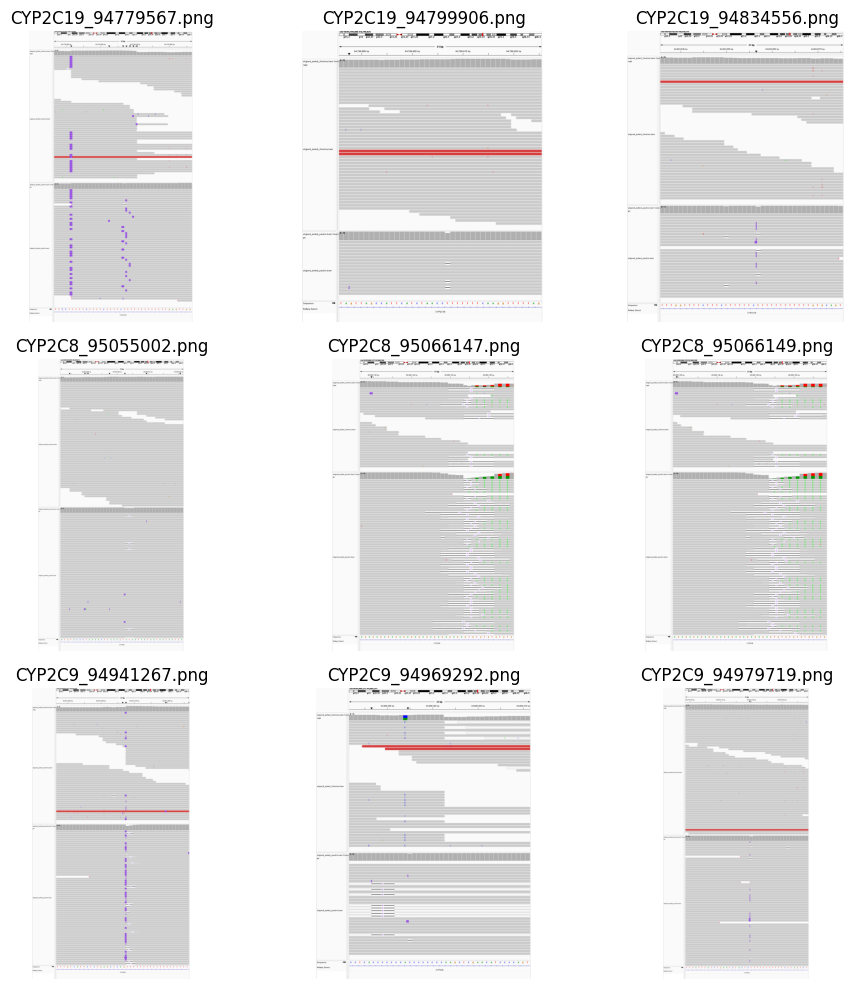

In [ ]:
%pip install -qcyvcf2
from cyvcf2 import VCF
from dataclasses import dataclass
import csv

@dataclass(frozen=True)
class Variant:
    '''
    Simple class for representing variants, this class is not meant to be used across multiple reference genomes. If it is, there will be issues as I do not check for this here.
    It's possible to handle this type of information, but I don't want to make my hash function any slower for a use-case that is not relevant to this assignment
    '''
    chromosome: str # This is the chromosome that the variant exists on
    ref_genome_position:int # This is the position in the reference genome where the variant starts
    ref_genome_string:str # This is the string in the reference genome that differs from the string in the sample
    sample_genome_alternates: str # This is the string in the sample that differs from the string in the reference genome
    notes:str

    def __eq__(self, other)-> bool:
        if isinstance(other, Variant):
            return (self.chromosome == other.chromosome and
            self.ref_genome_position == other.ref_genome_position )#and
            # self.ref_genome_string == other.ref_genome_string )#and
            # self.sample_genome_alternates == other.sample_genome_alternates)
        else:
            return False
    
    def __ne__(self, other) -> bool:
        return not self.__eq__(other)

    def __hash__(self):
        return hash((self.chromosome, self.ref_genome_position)) 
                    #  self.ref_genome_string,))# self.sample_genome_alternates, ))


    

pacbio_phased_variants_set = set()
for variant in VCF("data/gatk_output/pacbio.vcf.gz"):
        # Skip non-PASS
        if variant.FILTER not in (None, "PASS"):
            continue
        # Skip invalid or symbolic ALTs
        if not variant.ALT or any(a is None or a.startswith("<") or a == "*" for a in variant.ALT):
            continue
        # Skip if REF missing
        if not variant.REF or variant.REF == ".":
            continue
        alts = ",".join(sorted(list(variant.ALT)))
        variant_position = variant.POS
        ref_genome_str = variant.REF
        variant_chromosome = variant.CHROM
        record = Variant(chromosome= variant_chromosome, ref_genome_position=variant_position,  ref_genome_string=ref_genome_str, sample_genome_alternates=alts,notes="pacbio")
        pacbio_phased_variants_set.add(record)



illumina_phased_variants_set = set()
for variant in VCF("data/gatk_output/illumina.vcf.gz"):
    if variant.FILTER not in (None, "PASS"):
        continue
    # Skip invalid or symbolic ALTs
    if not variant.ALT or any(a is None or a.startswith("<") or a == "*" for a in variant.ALT):
        continue
    # Skip if REF missing
    if not variant.REF or variant.REF == ".":
        continue
    alts = ",".join(sorted(list(variant.ALT)))
    variant_position = variant.POS
    ref_genome_str = variant.REF
    variant_chromosome = variant.CHROM
    record = Variant(chromosome= variant_chromosome, ref_genome_position=variant_position,  ref_genome_string=ref_genome_str, sample_genome_alternates=alts, notes="illumina")
    illumina_phased_variants_set.add(record)



common_variants:set[Variant] = illumina_phased_variants_set.intersection(pacbio_phased_variants_set)

common_variants_list = sorted(list(common_variants), reverse=True,key= lambda variant: max([len(variant.ref_genome_string), len(variant.sample_genome_alternates)]))
num_common_variants = len(common_variants)

num_illumina_variants = len(illumina_phased_variants_set)
num_pacbio_variants = len(pacbio_phased_variants_set)

unique_illumina_vars_set = illumina_phased_variants_set.difference(common_variants)
unique_pacbio_vars_set = pacbio_phased_variants_set.difference(common_variants)
# print(common_variants)


num_variants_string = f'''There are {num_common_variants} shared across the illumina and pacbio VCF files.
There are {len(unique_illumina_vars_set)} variants sites unique to the illumina VCF file.
There are {len(unique_pacbio_vars_set)} variants sites unique to the pacbio VCF file.
Overlapping variants sites that do not match are considered unique.
The common variants have been dumped to data/notebook_outputs/common_variants.csv.
The variant distributions here vary from the variant distribution in vcftools as vcftools treats non-matching overlapping variant sites differently.
In this implementation a non-matching overlap site is not considered to be in-common or it's own category. Instead it is categorized as belonging
to the category of the sequencing technology of the sample where the variant was discovered.'''
print(num_variants_string)
with open("data/notebook_outputs/common_variants.csv", "w", newline="") as output_file:
    writer = csv.DictWriter(output_file, fieldnames = ["chromosome", "ref_genome_position", "ref_genome_string", "sample_genome_alternates", "notes"])
    writer.writeheader()
    writer.writerows(map(lambda variant: variant.__dict__,common_variants_list)) 





%pip install -qmatplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to your images directory
img_dir = "images"

# List all image files (png/jpg)
img_files = [f for f in os.listdir(img_dir) if f.endswith((".png", ".jpg", ".jpeg"))]

# Sort to make sure order is consistent
img_files.sort()

# Limit to 9 images
img_files = img_files[:9]

# Set up 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()  # Flatten 2D array to 1D for easy iteration

for ax, img_file in zip(axes, img_files):
    img_path = os.path.join(img_dir, img_file)
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(img_file)
    ax.axis('off')  # Hide axes

plt.tight_layout()
plt.show()



In [6]:

# Load the UCSC refGene table (downloaded from UCSC FTP)
# Columns for refGene table (from UCSC documentation)
colnames = ["bin","name","chrom","strand","txStart","txEnd","cdsStart","cdsEnd",
            "exonCount","exonStarts","exonEnds","score","name2","cdsStartStat",
            "cdsEndStat","exonFrames"]
# Read the gzipped refGene table

df = pd.read_csv("refGene.txt.gz", sep="\t", header=None, names=colnames, compression="gzip")

# Filter for your genes of interest
genes_of_interest = ["CYP2C8", "CYP2C9", "CYP2C19"]
subset = df[df["name2"].isin(genes_of_interest)]

# Build dictionary: key = gene name, value = (start, end)
gene_coords = {
    row["name2"]: (row["txStart"], row["txEnd"])
    for _, row in subset.iterrows()
}


joined_vars_list:list[Variant] = list(unique_pacbio_vars_set)
joined_vars_list.extend(list(unique_illumina_vars_set))
joined_vars_list.sort(reverse=True,key= lambda variant: max([len(variant.ref_genome_string), len(variant.sample_genome_alternates)]))

gene_variant_dict = dict(zip(genes_of_interest, [[] for _ in range(len(genes_of_interest))]))




cell_prompt = f"""We take a look at the longest non-common variants, keeping note of which technologies the variants are found in.
For each gene of interest in {genes_of_interest} we find 3 variants that lie within the gene of interest. We look at the BAM files for both """

def check_three_samples_for_each_gene(gene_variant_dict:dict[str, list]):
    gene_keys = gene_variant_dict.keys()
    for key in gene_keys:
        if len(gene_variant_dict[key]) < 3:
            return False
    return True
idx = 0
while (not check_three_samples_for_each_gene(gene_variant_dict) )and (idx < len(joined_vars_list)) :
    variant = joined_vars_list[idx]
    for gene in genes_of_interest:
        gene_window:tuple = gene_coords[gene]
        var_pos = variant.ref_genome_position
        if gene_window[0] <= var_pos <= gene_window[1] and len(gene_variant_dict[gene]) < 3:
            gene_variant_dict[gene].append(variant)
            break
    idx = idx + 1


for key, value in gene_variant_dict.items():
    print(f"{key}: {value}")






CYP2C8: [Variant(chromosome='chr10', ref_genome_position=95066147, ref_genome_string='AGAGAGAGTGTGTGT', sample_genome_alternates='A', notes='pacbio'), Variant(chromosome='chr10', ref_genome_position=95066149, ref_genome_string='AGAGAGTGTGTGT', sample_genome_alternates='A', notes='illumina'), Variant(chromosome='chr10', ref_genome_position=95055002, ref_genome_string='TATA', sample_genome_alternates='T', notes='pacbio')]
CYP2C9: [Variant(chromosome='chr10', ref_genome_position=94969292, ref_genome_string='CAAGCTCGAACAT', sample_genome_alternates='C', notes='illumina'), Variant(chromosome='chr10', ref_genome_position=94941267, ref_genome_string='G', sample_genome_alternates='GTT', notes='illumina'), Variant(chromosome='chr10', ref_genome_position=94954890, ref_genome_string='TA', sample_genome_alternates='T', notes='pacbio')]
CYP2C19: [Variant(chromosome='chr10', ref_genome_position=94779567, ref_genome_string='T', sample_genome_alternates='TTTTCTTTTC', notes='pacbio'), Variant(chromosom

The variants listed above do not appear to be true variants as they are not shared across sequencing technologies. The illumina and pacbio sequencing technologies used in the example do nothave the same read length for all reads. The illumina sample has more short reads that can be aligned to the reference genome, while the pacbio sample has longer reads that can cover more of the genome in one read. These shorter reads can be mapped in more locations across the genome, lowering the confidence of the variant calls that are made. Longer reads such as the pacbio reads are more likley to be mapped to a unique location in the genome, increasing the confidence of the variant calls that are made. In the cases where a variant is called in the illumina sample but not the pacbio sample, such as at CYP2C9_94969292 it is likely that the variant called in the illumina sample is a false positive due to the lower confidence of mapping short reads.

The alignments are pictured further below using a hack created by chatgpt to get past js not running in notebook cells.

In [ ]:
%pip install -q igv-notebook
%pip install -q igv-reports

import igv_notebook
import json

from itertools import chain
from igv_reports.report import create_report

print(gene_variant_dict)

positions_dict = {
    gene: [
        (
            v.ref_genome_position,
            v.ref_genome_position + max(
                len(v.ref_genome_string),
                len(sorted(v.sample_genome_alternates.split(","), key=len, reverse=True)[0])
            )
        )
        for v in variants
    ]
    for gene, variants in gene_variant_dict.items()
}

print(positions_dict)

rows = []
chromosome = "chr10"
for gene, pos_list in positions_dict.items():
    for start, end in pos_list:
        rows.append({
            "chromosome": chromosome, 
            "start": start,
            "end": end,
            "gene": gene
        })

sites_df = pd.DataFrame(rows)
sites_file = "sites.tsv"
sites_df.to_csv(sites_file, sep="\t", index=False)

bed_df = sites_df[['chromosome', 'start', 'end', 'gene']].copy()

# BED is 0-based, so subtract 1 from start
bed_df['start'] = bed_df['start'] - 1
bed_df.to_csv("sites.bed", sep="\t", header=False, index=False)

sites_df[['chromosome', 'start', 'end']].to_csv("sites.bed", sep="\t", header=False, index=False)



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
{'CYP2C8': [Variant(chromosome='chr10', ref_genome_position=95066147, ref_genome_string='AGAGAGAGTGTGTGT', sample_genome_alternates='A', notes='pacbio'), Variant(chromosome='chr10', ref_genome_position=95066149, ref_genome_string='AGAGAGTGTGTGT', sample_genome_alternates='A', notes='illumina'), Variant(chromosome='chr10', ref_genome_position=95055002, ref_genome_string='TATA', sample_genome_alternates='T', notes='pacbio')], 'CYP2C9': [Variant(chromosome='chr10', ref_genome_position=94969292, ref_genome_string='CAAGCTCGAACAT', sample_genome_alternates='C', notes='illumina'), Variant(chromosome='chr10', ref_genome_position=94941267, ref_genome_string='G', sample_genome_alternates='GTT', notes='illumina'), Variant(chromosome='chr10', ref_genome_position=94954890, ref_genome_string='TA', sample_genome_alternates='T', notes='pacbio')], 'CYP2C19': [Variant(chrom

In [22]:
%%bash


python -m igv_reports.report sites.tsv \
    --genome hg38 \
    --tracks ./data/alignments/aligned_sorted_illumina.bam ./data/alignments/aligned_sorted_pacbio.bam \
    --flanking 500 \
    --standalone \
    --sequence 1 \
    --begin 2 \
    --end 3 \
    --roi sites.bed \
    --output variant_report.html



Working on variant 1/9
Working on variant 2/9
Working on variant 3/9
Working on variant 4/9
Working on variant 5/9
Working on variant 6/9
Working on variant 7/9
Working on variant 8/9
Working on variant 9/9


In [ ]:
import threading
import http.server
import socketserver
from IPython.display import IFrame

PORT = 8000

handler = http.server.SimpleHTTPRequestHandler
httpd = socketserver.TCPServer(("", PORT), handler)

# Run server in a separate thread
import threading
threading.Thread(target=httpd.serve_forever, daemon=True).start()

# Embed the report
IFrame(f"http://localhost:{PORT}/variant_report.html", width="100%", height=600)



# Star Alelles
For CYP2C8, the star allele is CYP2C8*1.004 as the Guanine at position 95069813 is replaced with an Adenine.

For CYP2C9, the star allele is CYP2C9*5 as there is a swap of Cytosine to guanine at 94981301.

For CYP2C19 the star allele is CYP2C19*1B	as the cytosine at position 94762804 is replaced with a Thymine, and the adenine at 94842866 is replaced with a guanine.

Star alleles were found manually by looking up the shared variants within the PharmVar database.



# Growing pains:


Chatgpt was (GPT-5) was generally helpful for learning about some of the more well known tools for this project. It was useful in informing me about specific parameters of gatk HaplotypeCaller and minimap2. These parameters could all be found on the man pages/documentation for the tools as well. Chat-gpt was less than helpful when it came to troubleshooting smaller tools such as igv-notebook. There was an issue where my igv_notebook output was simply not displaying of my alignments. Because of this I initially saved igv snapshots generated with a batch script instead of using igv-notebook. Chat-gpt was helpful in demonstrating how to use the pharm-var database to automate star allele finding. I initially did this by hand, because each of the genes of interest can have variants in so many positions this was rather painful. In the future I will use automation to speed up this process.

